In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import Subset
from PIL import Image
import os

# Define your paths again so this notebook knows where to look
train_dir = 'data/train'
test_dir = 'data/test'

import torch
print(f"Total GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda:0") # Use the index of the NVIDIA card
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Total GPUs: 1
GPU 0: NVIDIA GeForce RTX 3080 Laptop GPU
Using device: cuda:0


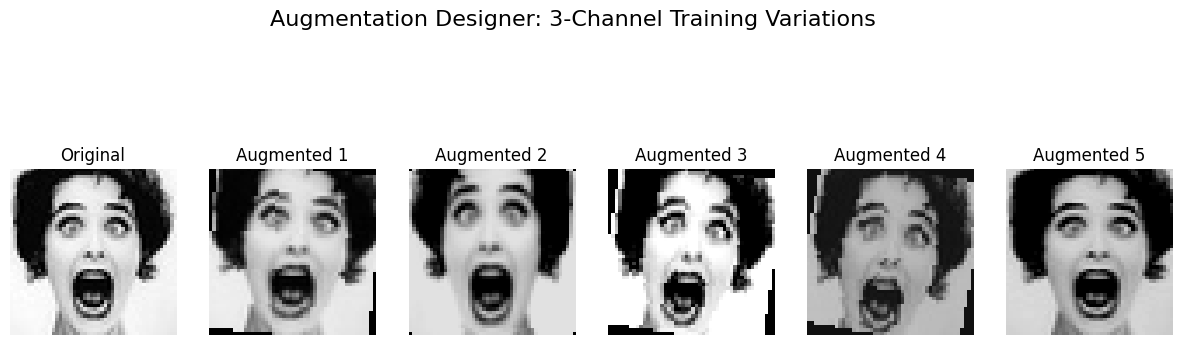

In [51]:
def visualize_augmentations(dataset, idx=0):
    plt.figure(figsize=(15, 5))
    
    # --- THE FIX FOR SUBSETS ---
    # If the dataset is a Subset, we need to find the real index in the original folder
    if isinstance(dataset, torch.utils.data.Subset):
        actual_idx = dataset.indices[idx]
        base_dataset = dataset.dataset
    else:
        actual_idx = idx
        base_dataset = dataset

    # 1. Show Original
    img_path, _ = base_dataset.samples[actual_idx]
    original_img = Image.open(img_path).convert('L')
    plt.subplot(1, 6, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 2. Show Augmented Versions
    for i in range(5):
        aug_tensor, _ = dataset[idx] # This still pulls the augmented version correctly
        
        # Convert from [3, 48, 48] to [48, 48, 3]
        aug_img = aug_tensor.numpy().transpose(1, 2, 0)
        
        # Undo the normalization for display
        aug_img = (aug_img * 0.5) + 0.5 
        aug_img = np.clip(aug_img, 0, 1) # Safety check for brightness/contrast
        
        plt.subplot(1, 6, i + 2)
        plt.imshow(aug_img) 
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
    plt.suptitle("Augmentation Designer: 3-Channel Training Variations", fontsize=16)
    plt.show()

visualize_augmentations(train_data, idx=0)

In [52]:
# --- AUGMENTATION DESIGNER ---
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomResizedCrop(48, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# --- DATA LOADERS (Optimized for Laptop GPU) ---
full_train_dataset = datasets.ImageFolder(root='data/train', transform=train_transform)

train_idx, val_idx = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    stratify=full_train_dataset.targets,
    random_state=42
)

train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_train_dataset, val_idx)

# pin_memory=True is crucial for NVIDIA GPUs on laptops
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [53]:
model = models.resnet18(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7) 
model = model.to(device)

# --- THE TUNING TOOLS ---
# Label smoothing helps the model stay "open-minded" about similar emotions
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Lower initial learning rate for better stability
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Scheduler: If accuracy doesn't improve for 2 epochs, cut LR by 90%
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

print("Model Architect: Fine-tuning mode engaged with Scheduler and Label Smoothing.")

Model Architect: Fine-tuning mode engaged with Scheduler and Label Smoothing.


In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
epochs = 20 # Increased epochs to give the scheduler time to work

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
    
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            
    train_loss /= len(train_data)
    train_acc = train_correct.double() / len(train_data)
    val_loss /= len(val_data)
    val_acc = val_correct.double() / len(val_data)
    
    # --- IMPORTANT: UPDATE THE SCHEDULER ---
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc.item())
    history['val_acc'].append(val_acc.item())
    
    print(f'Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}')

# Save progress immediately after training
torch.save(model.state_dict(), 'emotion_model_optimized.pth')

Epoch 1/20: Train Loss: 1.5789 | Val Acc: 0.5056 | LR: 0.000500
Epoch 2/20: Train Loss: 1.4012 | Val Acc: 0.5071 | LR: 0.000500
Epoch 3/20: Train Loss: 1.3516 | Val Acc: 0.5341 | LR: 0.000500
Epoch 4/20: Train Loss: 1.3253 | Val Acc: 0.5707 | LR: 0.000500
Epoch 5/20: Train Loss: 1.2938 | Val Acc: 0.5617 | LR: 0.000500
Epoch 6/20: Train Loss: 1.2714 | Val Acc: 0.5575 | LR: 0.000500
Epoch 7/20: Train Loss: 1.2588 | Val Acc: 0.5747 | LR: 0.000500
Epoch 8/20: Train Loss: 1.2353 | Val Acc: 0.5801 | LR: 0.000500
Epoch 9/20: Train Loss: 1.2188 | Val Acc: 0.5716 | LR: 0.000500


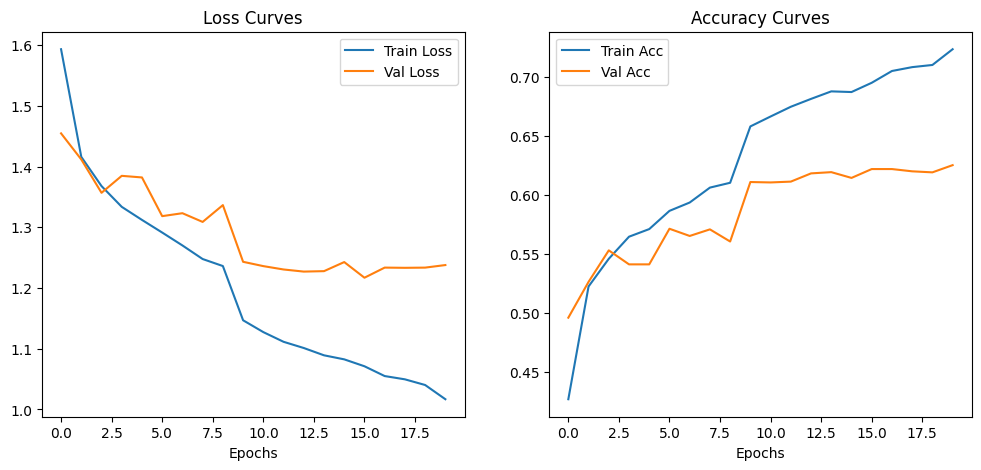

In [ ]:
def plot_curves(history):
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.show()

plot_curves(history)